In [8]:

%cd /home/jovyan/work

[Errno 2] No such file or directory: '/home/jovyan/work'
/home/llm-user/simulations


/home/llm-user/miniconda3/envs/cad_env/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [12]:
!#!pip install python-louvain

In [9]:
!ls -all

total 279432
drwxrwxr-x  5 llm-user llm-user      4096 Jun 29 09:06  .
drwxr-x--- 20 llm-user llm-user      4096 Jun 27 08:59  ..
-rw-rw-r--  1 llm-user llm-user      1392 Jun  4 12:23 '=2.0'
-rw-r--r--  1 llm-user users    264000128 May 29 14:42  adjacency_matrices.npy
-rw-r--r--  1 llm-user users      1704552 May 29 14:42  adjacency_matrices.npz
-rw-r--r--  1 llm-user users         1970 May 14 18:01  cuda_test.ipynb
-rw-rw-r--  1 llm-user llm-user   1457110 Jun  1 18:38 'DebuggerMay26 copy.ipynb'
-rw-rw-r--  1 llm-user llm-user   1552195 Jun 27 20:58  DebuggerMay26.ipynb
-rw-rw-r--  1 llm-user llm-user      9820 Jun  1 00:29  final_results1.npz
-rw-rw-r--  1 llm-user llm-user      9912 Jun  1 12:20  final_results2.npz
-rw-rw-r--  1 llm-user llm-user      8075 Jun  1 22:25  final_results3.npz
-rw-rw-r--  1 llm-user llm-user    400492 Jun 14 16:01  gaussian_bp_comparison.png
-rw-rw-r--  1 llm-user llm-user    403541 Jun 14 18:18  gaussian_bp_raw.png
-rw-rw-r--  1 llm-user llm-user     

In [10]:
import torch

# 1. Check if PyTorch can see the GPU
is_available = torch.cuda.is_available()
print(f"Is CUDA available? {is_available}")

# 2. If available, show details
if is_available:
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Device count: {torch.cuda.device_count()}")
else:
    print("CUDA is not available. Check your driver or image.")

Is CUDA available? True
GPU Device Name: NVIDIA RTX 4000 SFF Ada Generation
Device count: 1


In [11]:
import numpy as np
import time
import torch
import time
import sys
import scipy
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import networkx as nx
import random

## 1. Functions:

In [12]:
from scipy.stats import nbinom
import secrets
# ---------------- Utilidades para generar grafos ----------------
def generate_degrees(n, mean_k, var_k):
    """Genera una secuencia de grados con media y varianza aproximadas.
    This function's primary role is to create a sequence of degrees for a graph with $n$ nodes,
    ensuring the sequence adheres to a desired average degree ($\text{mean\_k}$) and
    degree variability ($\text{var\_k}$).
    It achieves this by sampling from a Negative Binomial distribution
    (a common choice for modeling real-world networks) and then performs necessary clean-up steps:
    it clips the degrees to be positive and less than $n$, and it adjusts one degree
    by $\pm 1$ if the total sum of degrees is odd, which is a mathematical requirement
    for a simple graph to exist.
    """


    if var_k <= mean_k:
        raise ValueError("La varianza debe ser mayor que la media para la Negativa Binomial.")
    p = mean_k / var_k
    r = mean_k * p / (1 - p)
    degs = nbinom(r, p).rvs(size=n)
    degs = np.clip(degs, 1, n-1)
    if np.sum(degs) % 2 == 1:
        idx = np.random.randint(0, n)
        degs[idx] += 1 if degs[idx] < n-1 else -1
    return degs

def ensure_connected(G):
    """Star repair: connect all components directly to the giant component."""
    if nx.is_connected(G):
        return G
    
    # Sort components by size, largest first
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    giant = components[0]  # anchor — everything connects here
    
    for small in components[1:]:
        u = random.choice(list(giant))   # node in giant
        v = random.choice(list(small))   # node in small component
        G.add_edge(u, v)
        giant = giant | small            # merge into giant
    
    assert nx.is_connected(G)
    return G


def generate_connected_graph(n=500, mean_k=6, var_k=20, seed=None):
    """Configuration model as primary constructor, with degree verification."""
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)  # also seed Python's random for NetworkX
    
    degrees = generate_degrees(n, mean_k, var_k)
    
    # Check graphicality first (Erdos-Gallai), then always use config model
    if not nx.is_valid_degree_sequence_erdos_gallai(degrees.tolist()):
        degrees[-1] += 1  # minimal fix — rare edge case
    
    G = nx.configuration_model(degrees)
    G = nx.Graph(G)                                 # collapse to simple graph
    G.remove_edges_from(nx.selfloop_edges(G))       # remove self-loops
    G = ensure_connected(G)
    
    # Verify realised statistics — always log these
    actual_degrees = [d for _, d in G.degree()]
    actual_mean = np.mean(actual_degrees)
    actual_var  = np.var(actual_degrees)
    print(f"Target  μ={mean_k:.2f}, σ²={var_k:.2f}")
    print(f"Realised μ={actual_mean:.2f}, σ²={actual_var:.2f}")
    
    return G

def generate_secure_seed():
    """
    Generates a cryptographically secure, 32-bit integer.
    This range (0 to 2**32 - 1) is fully compatible with np.random.seed().
    """
    return secrets.randbits(32)

## I. START: Create the Network treatments

In [27]:
N =400

In [28]:
import numpy as np
import networkx as nx

# --- Define helper for reproducible randomness ---
def generate_secure_seed():
    return np.random.randint(0, 1e6)

# --- Parameters ---
N = N
num_networks = 11          # 4 custom + WS + ER + Fully Connected + BA
num_replicas = 3

# Existing parameters for first 4 network types
mean_k_values = [10, 10, 40, 40]
var_k_values  = [14, 100, 44, 100]
seed_values   = [generate_secure_seed() for _ in range(num_networks)]

# Preallocate adjacency array
all_adj = np.zeros((num_networks, num_replicas, N, N), dtype=int)

# --- Generate the first 4 networks (custom generation) ---
for i, (mean_k, var_k, seed) in enumerate(zip(mean_k_values, var_k_values, seed_values[:4])):
    for r in range(num_replicas):
        print(f"Generating network {i+1}/8 (custom type), replica {r+1}/3")

        replica_seed = generate_secure_seed()
        graph = generate_connected_graph(
            n=N,
            mean_k=mean_k,
            var_k=var_k,
            seed=replica_seed
        )

        A = nx.to_numpy_array(graph, dtype=int)
        all_adj[i, r] = A

# --- 5.1 Watts–Strogatz small-world networks --- LOW MEAN
k_neighbors = 10   # each node connects to k nearest neighbors
p_rewire = 0.3    # rewiring probability

for r in range(num_replicas):
    print(f"Generating network 5/8 (Watts–Strogatz), replica {r+1}/3")
    seed = generate_secure_seed()
    G_ws = nx.watts_strogatz_graph(N, k_neighbors, p_rewire, seed=seed)
    A_ws = nx.to_numpy_array(G_ws, dtype=int)
    all_adj[4, r] = A_ws

# --- 5.2 Watts–Strogatz small-world networks --- HIGH MEAN
k_neighbors = 40   # each node connects to k nearest neighbors
p_rewire = 0.3    # rewiring probability

for r in range(num_replicas):
    print(f"Generating network 5/8 (Watts–Strogatz), replica {r+1}/3")
    seed = generate_secure_seed()
    G_ws = nx.watts_strogatz_graph(N, k_neighbors, p_rewire, seed=seed)
    A_ws = nx.to_numpy_array(G_ws, dtype=int)
    all_adj[5, r] = A_ws

# --- 6.1 Erdős–Rényi random networks --- LOW MEAN
p_edge = 0.01  # P = 6/1000 probability of connection

for r in range(num_replicas):
    print(f"Generating network 6/8 (Erdős–Rényi), replica {r+1}/3")
    seed = generate_secure_seed()
    G_er = nx.erdos_renyi_graph(N, p_edge, seed=seed)
    while not nx.is_connected(G_er):   # just try again — rare at p=0.006
        seed = generate_secure_seed()
        G_er = nx.erdos_renyi_graph(N, p_edge, seed=seed)
    A_er = nx.to_numpy_array(G_er, dtype=int)
    all_adj[6, r] = A_er

# --- 6.1 Erdős–Rényi random networks --- HIGH MEAN
p_edge = 0.04  # P = 6/1000 probability of connection

for r in range(num_replicas):
    print(f"Generating network 6/8 (Erdős–Rényi), replica {r+1}/3")
    seed = generate_secure_seed()
    G_er = nx.erdos_renyi_graph(N, p_edge, seed=seed)
    while not nx.is_connected(G_er):   # just try again — rare at p=0.006
        seed = generate_secure_seed()
        G_er = nx.erdos_renyi_graph(N, p_edge, seed=seed)
    A_er = nx.to_numpy_array(G_er, dtype=int)
    all_adj[7, r] = A_er

# --- 7. Fully Connected (Complete) Graph ---
for r in range(num_replicas):
    print(f"Generating network 7/8 (Fully Connected), replica {r+1}/3")
    G_fc = nx.complete_graph(N)
    A_fc = nx.to_numpy_array(G_fc, dtype=int)
    all_adj[8, r] = A_fc

# --- 8.1  Barabási–Albert (Scale-Free) Networks --- LOW
m_links = 5  # number of edges to attach from new node to existing nodes

for r in range(num_replicas):
    print(f"Generating network 8/8 (Barabási–Albert), replica {r+1}/3")
    seed = generate_secure_seed()
    G_ba = nx.barabasi_albert_graph(N, m_links, seed=seed)
    A_ba = nx.to_numpy_array(G_ba, dtype=int)
    all_adj[9, r] = A_ba

# --- 8.  Barabási–Albert (Scale-Free) Networks --- HIGH MEAN
m_links = 20 # number of edges to attach from new node to existing nodes

for r in range(num_replicas):
    print(f"Generating network 8/8 (Barabási–Albert), replica {r+1}/3")
    seed = generate_secure_seed()
    G_ba = nx.barabasi_albert_graph(N, m_links, seed=seed)
    A_ba = nx.to_numpy_array(G_ba, dtype=int)
    all_adj[10, r] = A_ba

# --- Save results ---
np.save("adjacency_matrices200.npy", all_adj)
np.savez_compressed("adjacency_matrices200.npz", adjacency_matrices=all_adj)
print("Saved 8 network groups × 3 replicas to adjacency_matrices200.npz")

Generating network 1/8 (custom type), replica 1/3
Target  μ=10.00, σ²=14.00
Realised μ=9.85, σ²=14.25
Generating network 1/8 (custom type), replica 2/3
Target  μ=10.00, σ²=14.00
Realised μ=9.70, σ²=12.06
Generating network 1/8 (custom type), replica 3/3
Target  μ=10.00, σ²=14.00
Realised μ=9.91, σ²=13.43
Generating network 2/8 (custom type), replica 1/3
Target  μ=10.00, σ²=100.00
Realised μ=9.76, σ²=90.48
Generating network 2/8 (custom type), replica 2/3
Target  μ=10.00, σ²=100.00
Realised μ=9.04, σ²=93.41
Generating network 2/8 (custom type), replica 3/3
Target  μ=10.00, σ²=100.00
Realised μ=10.12, σ²=95.36
Generating network 3/8 (custom type), replica 1/3
Target  μ=40.00, σ²=44.00
Realised μ=37.23, σ²=39.35
Generating network 3/8 (custom type), replica 2/3
Target  μ=40.00, σ²=44.00
Realised μ=38.02, σ²=41.93
Generating network 3/8 (custom type), replica 3/3
Target  μ=40.00, σ²=44.00
Realised μ=38.48, σ²=32.26
Generating network 4/8 (custom type), replica 1/3
Target  μ=40.00, σ²=100.0

In [22]:
all_adj.shape

(11, 3, 400, 400)

## Loading when there is saved data

In [23]:
# Load the compressed .npz file
data = np.load("adjacency_matrices.npz")
# Access the matrices using the key used during saving
all_adj = data["adjacency_matrices"]

## Graph 2. comparing treatments

## Average +- Sd: 

## Metrics

In [19]:
#!pip install python-louvain
#!pip install igraph
!pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 81.5 MB/s  0:00:00


In [20]:
import numpy as np
import networkx as nx
import community as community_louvain
import igraph as ig
import leidenalg
from scipy.linalg import eigvals
from scipy.stats import entropy as shannon_entropy, powerlaw


def compute_sc_properties(G):
    """
    Compute global structural connectivity (SC) properties.
    """

    results = {}

    # ---------------- Basic ----------------
    N = G.number_of_nodes()
    results["Network size"] = N

    degrees = np.array([d for _, d in G.degree()])
    results["Mean degree"] = degrees.mean()
    results["Variance of degree"] = degrees.var()

    # ---------------- Clustering ----------------
    results["Clustering coefficient"] = nx.average_clustering(G)

    # ---------------- Path length ----------------
    if nx.is_connected(G):
        results["Shortest path length"] = nx.average_shortest_path_length(G)
    else:
        results["Shortest path length"] = np.nan

    # ---------------- Efficiency ----------------
    results["Global efficiency"] = nx.global_efficiency(G)

    # ---------------- Eigenvector centrality ----------------
    ec = nx.eigenvector_centrality_numpy(G)
    results["Eigenvector centrality"] = np.mean(list(ec.values()))

    # ---------------- Assortativity ----------------
    results["Assortativity coefficient"] = nx.degree_assortativity_coefficient(G)

    # ---------------- Modularity ----------------
    #partition = community_louvain.best_partition(G)
    #results["Modularity"] = community_louvain.modularity(partition, G)

    G_ig = ig.Graph.from_networkx(G)
    partition = leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition)
    results["Modularity"] = partition.modularity

    # ---------------- Heterogeneity ----------------
    results["Heterogeneity score"] = degrees.std() / degrees.mean()

    # ---------------- Entropy ----------------
    hist, _ = np.histogram(degrees, bins="auto", density=True)
    hist = hist[hist > 0]
    results["Entropy"] = shannon_entropy(hist)

    # ---------------- Spectral gap ----------------
    L = nx.laplacian_matrix(G).toarray()
    eigs = np.sort(np.real(eigvals(L)))
    results["Spectral gap"] = eigs[1] if len(eigs) > 1 else np.nan

    return results


In [21]:
all_adj.shape

(11, 3, 1000, 1000)

## Calculating stats among three replicates

In [22]:
import numpy as np
import networkx as nx

def adj_to_graph(adj):
    return nx.from_numpy_array(adj)

def compute_replicate_stats(all_adj, compute_func):
    """
    all_adj: shape (8, 3, N, N)
    compute_func: function like compute_sc_properties or compute_mean_nodal_sc_properties

    Returns:
        dict[topology][metric] = (mean, std)
    """

    n_topologies = all_adj.shape[0]
    n_reps = all_adj.shape[1]

    final_results = {}

    for topo in range(n_topologies):
        replica_results = []

        for rep in range(n_reps):
            adj = all_adj[topo, rep]
            G = adj_to_graph(adj)

            metrics = compute_func(G)
            replica_results.append(metrics)

        # Convert list of dicts → dict of lists
        keys = replica_results[0].keys()
        aggregated = {}

        for k in keys:
            values = np.array([r[k] for r in replica_results], dtype=float)

            aggregated[k] = {
                "mean": np.nanmean(values),
                "std": np.nanstd(values)
            }

        final_results[topo] = aggregated

    return final_results

In [23]:
global_stats = compute_replicate_stats(all_adj, compute_sc_properties)

/opt/conda/lib/python3.13/site-packages/networkx/algorithms/assortativity/correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))
/tmp/ipykernel_326/2015636118.py:39: RuntimeWarning: Mean of empty slice
  "mean": np.nanmean(values),
/opt/conda/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [24]:
import pandas as pd

network_names = [
    "LL",
    "LH",
    "HL",
    "HH",
    "Watts–Strogatz Low mean",
    "Watts–Strogatz High mean",
    "Erdős–Rényi Low mean",
    "Erdős–Rényi High mean",
    "Fully Connected",
    "Barabási–Albert Low mean",
    "Barabási–Albert High mean"
]

def results_to_sorted_df(results, network_names):
    rows = []

    for topo_idx, metrics in results.items():
        row = {"Network": network_names[topo_idx]}

        for metric, stats in metrics.items():
            if metric == "Network size":
                continue  #  remove it

            mean = stats["mean"]
            std = stats["std"]

            row[metric] = f"{mean:.3f} ± {std:.3f}"
            row[f"{metric}_mean"] = mean  # helper for sorting

        rows.append(row)

    df = pd.DataFrame(rows).set_index("Network")

    #  Sort by modularity (numeric)
    df = df.sort_values(by="Clustering coefficient", ascending=True)

    #  Remove helper columns
    df = df[[col for col in df.columns if not col.endswith("_mean")]]

    #  Move "Modularity" to first column
    cols = df.columns.tolist()
    cols.insert(0, cols.pop(cols.index("Modularity")))
    df = df[cols]

    return df

def compute_replicate_raw(all_adj, compute_func):
    n_topologies = all_adj.shape[0]
    n_reps = all_adj.shape[1]

    raw_results = {}

    for topo in range(n_topologies):
        raw_results[topo] = {}

        for rep in range(n_reps):
            G = nx.from_numpy_array(all_adj[topo, rep])
            metrics = compute_func(G)

            for k, v in metrics.items():
                raw_results[topo].setdefault(k, []).append(v)

    return raw_results

def plot_boxplot(raw_results, metric_name):
    data = []
    labels = []

    for topo in sorted(raw_results.keys()):
        values = raw_results[topo][metric_name]
        data.append(values)
        labels.append(f"T{topo}")

    plt.figure()
    plt.boxplot(data, labels=labels)
    plt.xlabel("Topology")
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} distribution across replicas")

    plt.show()
    
results_table = results_to_sorted_df(global_stats, network_names)
df_display = results_table.drop(
    columns=["Spectral gap", "Assortativity coefficient", "Eigenvector centrality", "Global efficiency"], 
    errors="ignore"
)
df_display = df_display.sort_values(
    by="Modularity", 
    ascending=True,
    key=lambda col: col.str.split(' ').str[0].astype(float)
)

In [25]:
df_display

,Modularity,Mean degree,Variance of degree,Clustering coefficient,Shortest path length,Heterogeneity score,Entropy
Network,,,,,,,
Fully Connected,0.000 ± 0.000,999.000 ± 0.000,0.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000
Barabási–Albert High mean,0.130 ± 0.001,39.200 ± 0.000,871.148 ± 12.350,0.095 ± 0.001,2.168 ± 0.001,0.753 ± 0.005,2.520 ± 0.019
Erdős–Rényi High mean,0.136 ± 0.002,39.950 ± 0.171,38.070 ± 2.444,0.040 ± 0.000,2.155 ± 0.002,0.154 ± 0.005,2.722 ± 0.025
HH,0.137 ± 0.002,39.088 ± 0.154,91.824 ± 3.721,0.042 ± 0.001,2.176 ± 0.002,0.245 ± 0.004,2.698 ± 0.060
HL,0.140 ± 0.003,39.311 ± 0.163,42.731 ± 0.598,0.040 ± 0.000,2.166 ± 0.003,0.166 ± 0.001,2.691 ± 0.010
LH,0.286 ± 0.006,9.795 ± 0.201,90.210 ± 7.499,0.030 ± 0.003,3.254 ± 0.032,0.969 ± 0.031,2.421 ± 0.052
Barabási–Albert Low mean,0.294 ± 0.003,9.950 ± 0.000,105.120 ± 3.980,0.040 ± 0.002,2.977 ± 0.012,1.030 ± 0.020,1.896 ± 0.045
Erdős–Rényi Low mean,0.302 ± 0.001,9.933 ± 0.063,9.615 ± 0.356,0.010 ± 0.000,3.265 ± 0.010,0.312 ± 0.005,2.533 ± 0.017
LL,0.304 ± 0.001,9.943 ± 0.121,13.967 ± 0.554,0.011 ± 0.000,3.254 ± 0.018,0.376 ± 0.009,2.696 ± 0.010


In [26]:
df_display = df_display.sort_values(
    by="Mean degree", 
    ascending=True,
    key=lambda col: col.str.split(' ').str[0].astype(float)
)

In [27]:
df_display

,Modularity,Mean degree,Variance of degree,Clustering coefficient,Shortest path length,Heterogeneity score,Entropy
Network,,,,,,,
LH,0.286 ± 0.006,9.795 ± 0.201,90.210 ± 7.499,0.030 ± 0.003,3.254 ± 0.032,0.969 ± 0.031,2.421 ± 0.052
Erdős–Rényi Low mean,0.302 ± 0.001,9.933 ± 0.063,9.615 ± 0.356,0.010 ± 0.000,3.265 ± 0.010,0.312 ± 0.005,2.533 ± 0.017
LL,0.304 ± 0.001,9.943 ± 0.121,13.967 ± 0.554,0.011 ± 0.000,3.254 ± 0.018,0.376 ± 0.009,2.696 ± 0.010
Barabási–Albert Low mean,0.294 ± 0.003,9.950 ± 0.000,105.120 ± 3.980,0.040 ± 0.002,2.977 ± 0.012,1.030 ± 0.020,1.896 ± 0.045
Watts–Strogatz Low mean,0.635 ± 0.008,10.000 ± 0.000,2.547 ± 0.122,0.239 ± 0.007,3.612 ± 0.018,0.160 ± 0.004,1.869 ± 0.020
HH,0.137 ± 0.002,39.088 ± 0.154,91.824 ± 3.721,0.042 ± 0.001,2.176 ± 0.002,0.245 ± 0.004,2.698 ± 0.060
Barabási–Albert High mean,0.130 ± 0.001,39.200 ± 0.000,871.148 ± 12.350,0.095 ± 0.001,2.168 ± 0.001,0.753 ± 0.005,2.520 ± 0.019
HL,0.140 ± 0.003,39.311 ± 0.163,42.731 ± 0.598,0.040 ± 0.000,2.166 ± 0.003,0.166 ± 0.001,2.691 ± 0.010
Erdős–Rényi High mean,0.136 ± 0.002,39.950 ± 0.171,38.070 ± 2.444,0.040 ± 0.000,2.155 ± 0.002,0.154 ± 0.005,2.722 ± 0.025


In [43]:
network_names

['LL',
 'LH',
 'HL',
 'HH',
 'Watts–Strogatz Low mean',
 'Watts–Strogatz High mean',
 'Erdős–Rényi Low mean',
 'Erdős–Rényi High mean',
 'Fully Connected',
 'Barabási–Albert Low mean',
 'Barabási–Albert High mean']

In [44]:
n_rows

4

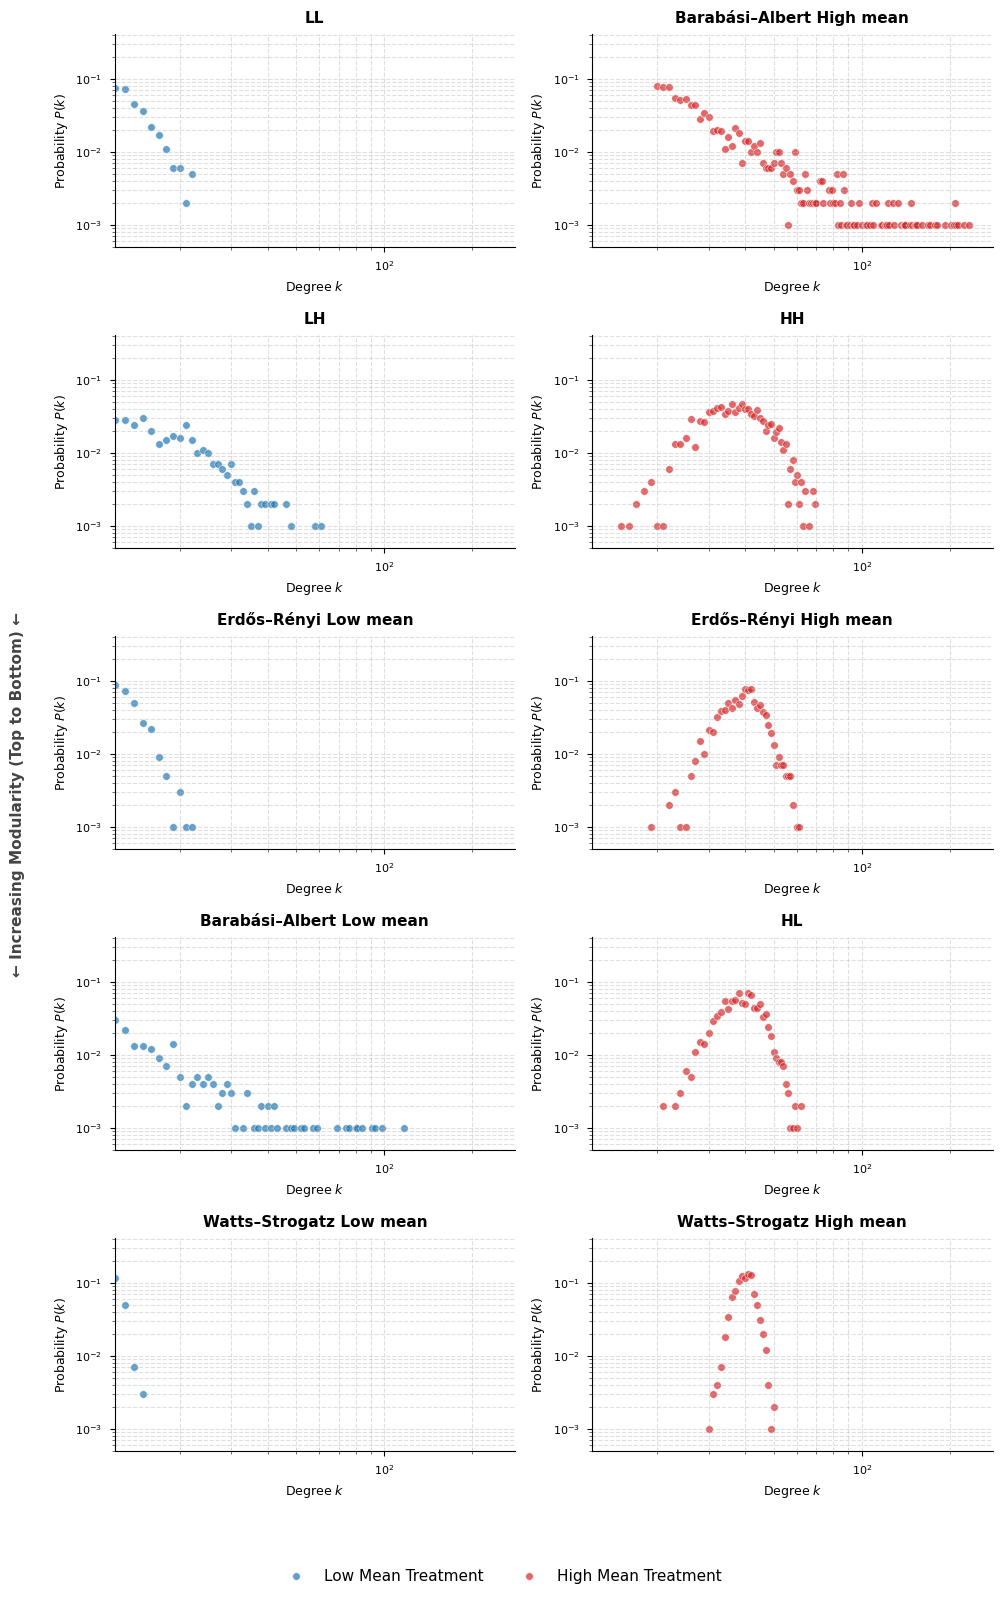

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import collections

# Professional styling
plt.style.use('seaborn-v0_8-paper') 

network_names = [
    'LL', 'LH', 'HL', 'HH',
    'Watts–Strogatz Low mean', 'Watts–Strogatz High mean',
    'Erdős–Rényi Low mean', 'Erdős–Rényi High mean',
    'Fully Connected',
    'Barabási–Albert Low mean', 'Barabási–Albert High mean'
]

# Organized from top (least modular) to bottom (highest modular)
list_low_mean = ["LL", "LH", "Erdős–Rényi Low mean", "Barabási–Albert Low mean", "Watts–Strogatz Low mean"]
list_high_mean = ["Barabási–Albert High mean", "HH", "Erdős–Rényi High mean",  "HL", "Watts–Strogatz High mean"]

all_targeted_plots = list_low_mean + list_high_mean

# ==========================================
# 1. FIND STANDARDIZED AXES LIMITS
# ==========================================
global_min_k, global_max_k = float('inf'), float('-inf')
global_min_pk, global_max_pk = float('inf'), float('-inf')

for target_name in all_targeted_plots:
    if target_name in network_names:
        net_idx = network_names.index(target_name)
        adj = all_adj[net_idx, 0] 
        degrees = np.sum(adj, axis=1)
        
        counts = collections.Counter(degrees)
        N_nodes = adj.shape[0]
        
        k_values = np.array(list(counts.keys()))
        pk_values = np.array([counts[k] / N_nodes for k in k_values])
        
        valid_k = k_values[k_values > 0]
        valid_pk = pk_values[pk_values > 0]
        
        if target_name in list_high_mean and len(valid_k) > 0:
            global_min_k = min(global_min_k, np.min(valid_k))
            global_max_k = max(global_max_k, np.max(valid_k))
            
        if len(valid_pk) > 0:
            global_min_pk = min(global_min_pk, np.min(valid_pk))
            global_max_pk = max(global_max_pk, np.max(valid_pk))

x_lim_min, x_lim_max = global_min_k * 0.8, global_max_k * 1.2
y_lim_min, y_lim_max = global_min_pk * 0.5, global_max_pk * 1.5

# ==========================================
# 2. PLOTTING
# ==========================================
n_rows = max(len(list_low_mean), len(list_high_mean))

fig, axes = plt.subplots(n_rows, 2, figsize=(10, 3.2 * n_rows), dpi=100)
plt.subplots_adjust(hspace=0.5, wspace=0.3)

scatter_low = None
scatter_high = None

for row_idx in range(n_rows):
    for col_idx, current_list in enumerate([list_low_mean, list_high_mean]):
        ax = axes[row_idx, col_idx]
        
        if row_idx < len(current_list):
            target_name = current_list[row_idx]
            
            try:
                net_idx = network_names.index(target_name)
            except ValueError:
                ax.axis('off')
                continue

            adj = all_adj[net_idx, 0] 
            degrees = np.sum(adj, axis=1)
            counts = collections.Counter(degrees)
            N_nodes = adj.shape[0]
            
            k_values = sorted(counts.keys())
            pk_values = [counts[k] / N_nodes for k in k_values]
            
            color = '#1f77b4' if col_idx == 0 else '#d62728' 
            sc = ax.scatter(k_values, pk_values, alpha=0.7, s=30, 
                            color=color, edgecolor='white', linewidth=0.5)
            
            if col_idx == 0 and scatter_low is None:
                scatter_low = sc
            elif col_idx == 1 and scatter_high is None:
                scatter_high = sc
            
            ax.set_title(target_name, fontsize=11, fontweight='bold', pad=8)
            ax.set_xlabel("Degree $k$", fontsize=9)
            ax.set_ylabel("Probability $P(k)$", fontsize=9)
            
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlim(x_lim_min, x_lim_max)
            ax.set_ylim(y_lim_min, y_lim_max)
            
            ax.grid(True, which="both", linestyle='--', alpha=0.4)
            ax.tick_params(labelsize=8)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
        else:
            ax.axis('off')

# ==========================================
# 3. GLOBAL LEGEND & ANNOTATIONS
# ==========================================
fig.legend(
    [scatter_low, scatter_high], 
    ['Low Mean Treatment', 'High Mean Treatment'], 
    loc='lower center', 
    ncol=2, 
    fontsize=11,
    frameon=True, 
    facecolor='white', 
    edgecolor='none'
)

fig.text(
    0.01, 0.5, '← Increasing Modularity (Top to Bottom) ←', 
    va='center', ha='center', rotation='vertical', 
    fontsize=11, fontweight='semibold', color='#444444'
)

# Crucial: Using rect to make sure the tight bounding box doesn't overlap the custom margin text/legend
plt.tight_layout(rect=[0.03, 0.05, 1, 1])

# Save outputs with tight bounding boxes for seamless journal integration
plt.savefig("network_distributions_final.png", dpi=300, bbox_inches='tight')
plt.savefig("network_distributions_final.pdf", format='pdf', bbox_inches='tight')

plt.show()

In [49]:

print(results[0].keys())

dict_keys(['Network size', 'Mean degree', 'Variance of degree', 'Clustering coefficient', 'Shortest path length', 'Global efficiency', 'Eigenvector centrality', 'Assortativity coefficient', 'Modularity', 'Heterogeneity score', 'Entropy', 'Spectral gap'])


In [50]:
results[0]["Shortest path length"]

{'mean': np.float64(3.2535362028695363),
 'std': np.float64(0.017956172384954405)}

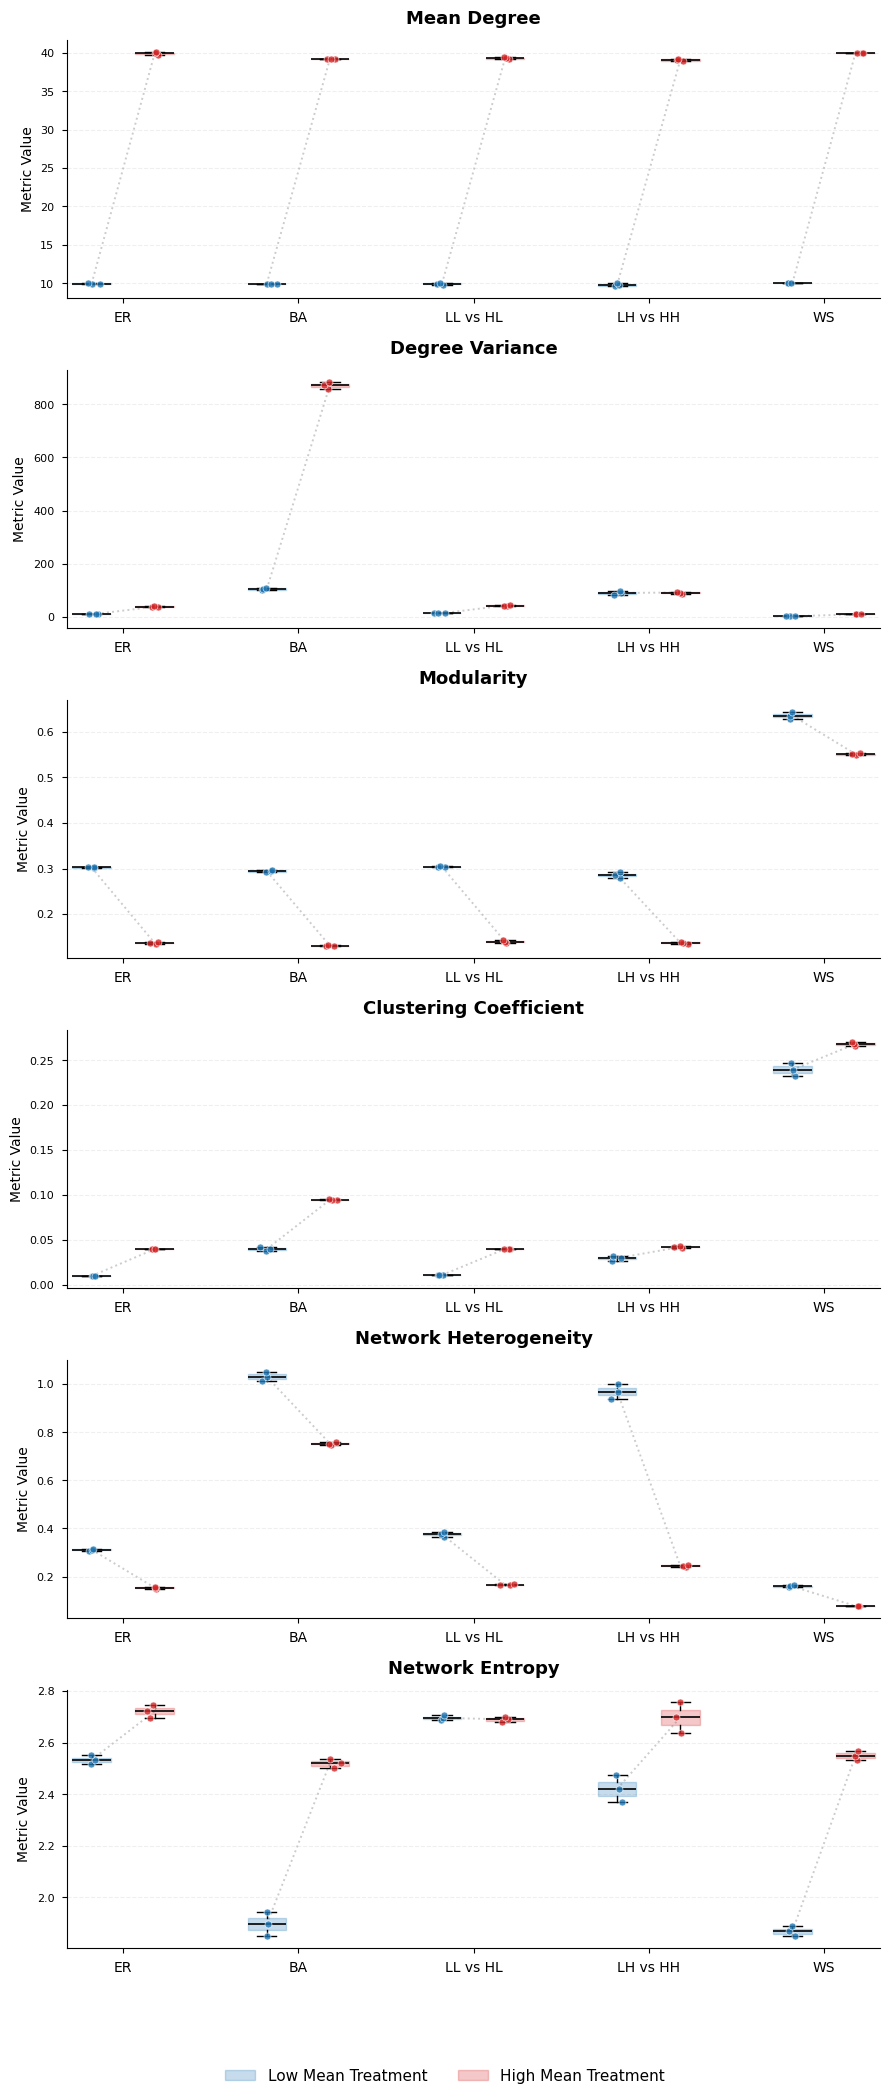

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate data first
results = global_stats.copy()

# Professional styling
plt.style.use('seaborn-v0_8-paper')

network_names = [
    'LL', 'LH', 'HL', 'HH',
    'Watts–Strogatz Low mean', 'Watts–Strogatz High mean',
    'Erdős–Rényi Low mean', 'Erdős–Rényi High mean',
    'Fully Connected',
    'Barabási–Albert Low mean', 'Barabási–Albert High mean'
]

pairs_to_compare = [
    ("Erdős–Rényi Low mean", "Erdős–Rényi High mean"),
    ("Barabási–Albert Low mean", "Barabási–Albert High mean"),
    ("LL", "HL"),
    ("LH", "HH"),
    ("Watts–Strogatz Low mean", "Watts–Strogatz High mean")
]
pair_labels = ["ER", "BA", "LL vs HL", "LH vs HH", "WS"]

# CRITICAL: Ensure these lists are the same length
metrics_to_plot = [
    'Mean degree', 
    'Variance of degree', 
    'Modularity', 
    'Clustering coefficient', 
    'Heterogeneity score',
    'Entropy'  # Ensure this matches your dict_keys exactly
]

metric_titles = [
    "Mean Degree", 
    "Degree Variance", 
    "Modularity", 
    "Clustering Coefficient", 
    "Network Heterogeneity",
    "Network Entropy"
]

# ==========================================
# 2. PLOTTING SETUP
# ==========================================
n_metrics = len(metrics_to_plot)
fig, axes = plt.subplots(n_metrics, 1, figsize=(9, 3.5 * n_metrics), dpi=100)

if n_metrics == 1:
    axes = [axes]

color_low = '#1f77b4'   
color_high = '#d62728'  

for m_idx, metric_key in enumerate(metrics_to_plot):
    ax = axes[m_idx]
    
    data_low, pos_low = [], []
    data_high, pos_high = [], []
    
    for x_pos, (low_name, high_name) in enumerate(pairs_to_compare):
        low_idx = network_names.index(low_name) if low_name in network_names else None
        high_idx = network_names.index(high_name) if high_name in network_names else None
        
        y_low_val, y_high_val = None, None
        
        if low_idx is not None and metric_key in results.get(low_idx, {}):
            low_stats = results[low_idx][metric_key]
            vals = low_stats.get("values", np.array([low_stats["mean"]-low_stats["std"], low_stats["mean"], low_stats["mean"]+low_stats["std"]]))
            data_low.append(vals)
            pos_low.append(x_pos + 1 - 0.18)
            y_low_val = np.median(vals)
            
        if high_idx is not None and metric_key in results.get(high_idx, {}):
            high_stats = results[high_idx][metric_key]
            vals = high_stats.get("values", np.array([high_stats["mean"]-high_stats["std"], high_stats["mean"], high_stats["mean"]+high_stats["std"]]))
            data_high.append(vals)
            pos_high.append(x_pos + 1 + 0.18)
            y_high_val = np.median(vals)
            
        if y_low_val is not None and y_high_val is not None:
            ax.plot([x_pos + 1 - 0.18, x_pos + 1 + 0.18], [y_low_val, y_high_val], 
                    color='gray', linestyle=':', alpha=0.4, zorder=1)

    # Boxplots
    bp_l = ax.boxplot(data_low, positions=pos_low, widths=0.22, patch_artist=True, showfliers=False,
                      boxprops=dict(facecolor=color_low, color=color_low, alpha=0.25),
                      medianprops=dict(color='black', linewidth=1.2))

    bp_h = ax.boxplot(data_high, positions=pos_high, widths=0.22, patch_artist=True, showfliers=False,
                      boxprops=dict(facecolor=color_high, color=color_high, alpha=0.25),
                      medianprops=dict(color='black', linewidth=1.2))

    # Jittered Points
    for i, points in enumerate(data_low):
        x_jitter = np.random.normal(pos_low[i], 0.02, size=len(points))
        ax.scatter(x_jitter, points, color=color_low, s=25, edgecolor='white', linewidth=0.5, alpha=0.8, zorder=3)

    for i, points in enumerate(data_high):
        x_jitter = np.random.normal(pos_high[i], 0.02, size=len(points))
        ax.scatter(x_jitter, points, color=color_high, s=25, edgecolor='white', linewidth=0.5, alpha=0.8, zorder=3)

    # Styling
    ax.set_title(metric_titles[m_idx], fontsize=13, fontweight='bold', pad=12)
    ax.set_xticks(range(1, len(pairs_to_compare) + 1))
    ax.set_xticklabels(pair_labels, fontsize=10)
    ax.set_ylabel("Metric Value", fontsize=10)
    
    # Ensure Entropy (often 0-1 or very small range) has a clean view
    ax.relim()
    ax.autoscale_view()
    
    ax.grid(True, axis='y', linestyle='--', alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.legend(
    [bp_l["boxes"][0], bp_h["boxes"][0]], 
    ['Low Mean Treatment', 'High Mean Treatment'], 
    loc='lower center', ncol=2, fontsize=11, frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("network_metrics_with_entropy.png", dpi=300, bbox_inches='tight')
plt.show()

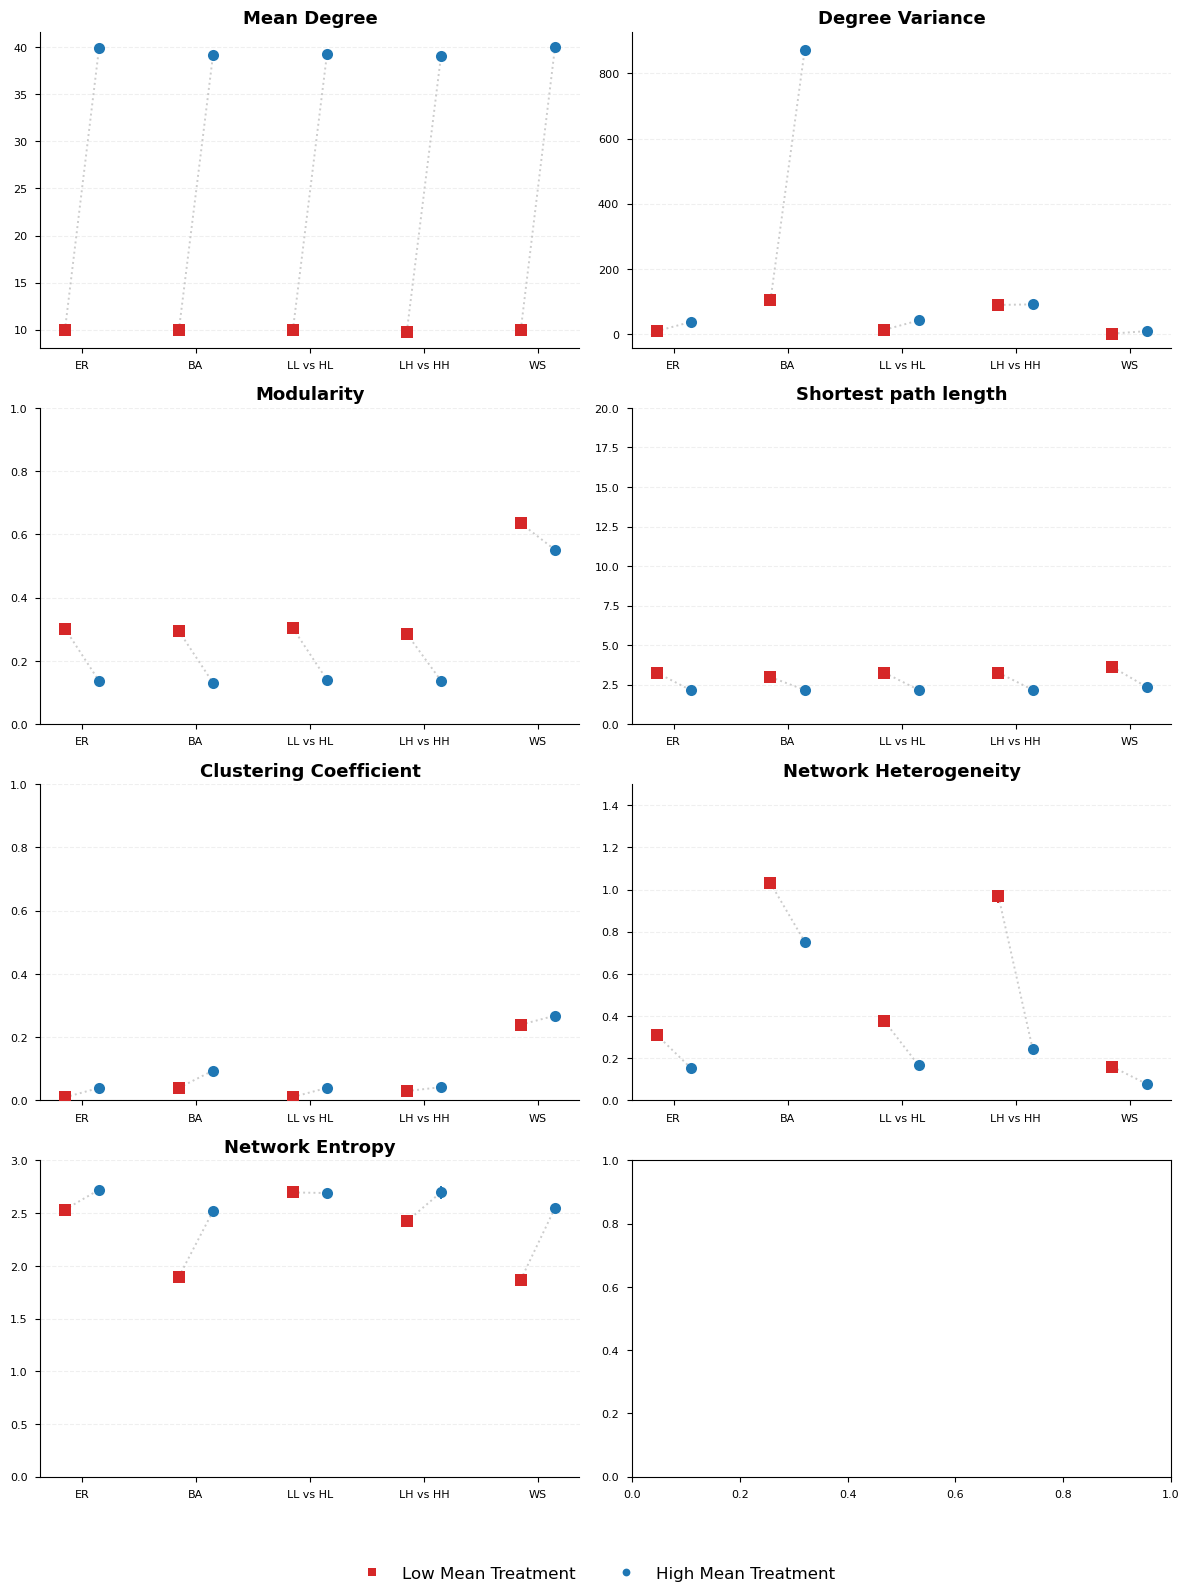

In [57]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# --- CONFIGURATION ---
colors = ['#d62728', '#1f77b4'] 
markers = ['s', 'o'] 

metric_map = {
    'Mean Degree': 'Mean degree',
    'Degree Variance': 'Variance of degree',
    'Modularity': 'Modularity',
    'Shortest path length': 'Shortest path length',
    'Clustering Coefficient': 'Clustering coefficient',
    'Network Heterogeneity': 'Heterogeneity score',
    'Network Entropy': 'Entropy'
}

ylim_map = {
    'Modularity': (0, 1),
    'Shortest path length': (0, 20),
    'Clustering Coefficient': (0, 1),
    'Network Heterogeneity': (0, 1.5),
    'Network Entropy': (0, 3)
}

# --- PLOTTING ---
fig, axes = plt.subplots(4, 2, figsize=(12, 16), dpi=100)
flat_axes = axes.flatten()

for m_idx, (title, actual_key) in enumerate(metric_map.items()):
    ax = flat_axes[m_idx]
    found_any = False

    for x_pos, (low_name, high_name) in enumerate(pairs_to_compare):
        # Resolve indices
        low_idx = network_names.index(low_name) if low_name in network_names else None
        high_idx = network_names.index(high_name) if high_name in network_names else None
        
        # Plot Low (Square)
        if low_idx is not None and actual_key in results[low_idx]:
            low_stats = results[low_idx][actual_key]
            ax.errorbar(
                x_pos + 1 - 0.15,
                low_stats.get('mean', 0),
                yerr=low_stats.get('std', 0),
                fmt=markers[0],
                color=colors[0],
                capsize=4,
                markersize=8,
                zorder=5
            )
            found_any = True
            low_value = low_stats.get('mean', 0)
        else:
            low_value = None
            
        # Plot High (Circle)
        if high_idx is not None and actual_key in results[high_idx]:
            high_stats = results[high_idx][actual_key]
            ax.errorbar(
                x_pos + 1 + 0.15,
                high_stats.get('mean', 0),
                yerr=high_stats.get('std', 0),
                fmt=markers[1],
                color=colors[1],
                capsize=4,
                markersize=8,
                zorder=5
            )
            found_any = True
            high_value = high_stats.get('mean', 0)
        else:
            high_value = None

        if low_value is not None and high_value is not None:
            ax.plot([x_pos + 1 - 0.15, x_pos + 1 + 0.15], [low_value, high_value],
                    color='gray', linestyle=':', alpha=0.4, zorder=1)
            
    if not found_any:
        print(f"DEBUG: No data found for key: '{actual_key}'")

    # Styling
    ax.set_title(title, fontsize=13, fontweight='bold')
    if title in ylim_map: ax.set_ylim(ylim_map[title])
    ax.set_xticks(range(1, len(pairs_to_compare) + 1))
    ax.set_xticklabels(pair_labels, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.2)

# Legend
low_h = mlines.Line2D([], [], color=colors[0], marker=markers[0], linestyle='None', label='Low Mean Treatment')
high_h = mlines.Line2D([], [], color=colors[1], marker=markers[1], linestyle='None', label='High Mean Treatment')
fig.legend(handles=[low_h, high_h], loc='lower center', ncol=2, frameon=False, fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("network_metrics_final.png", dpi=300, bbox_inches='tight')
plt.show()


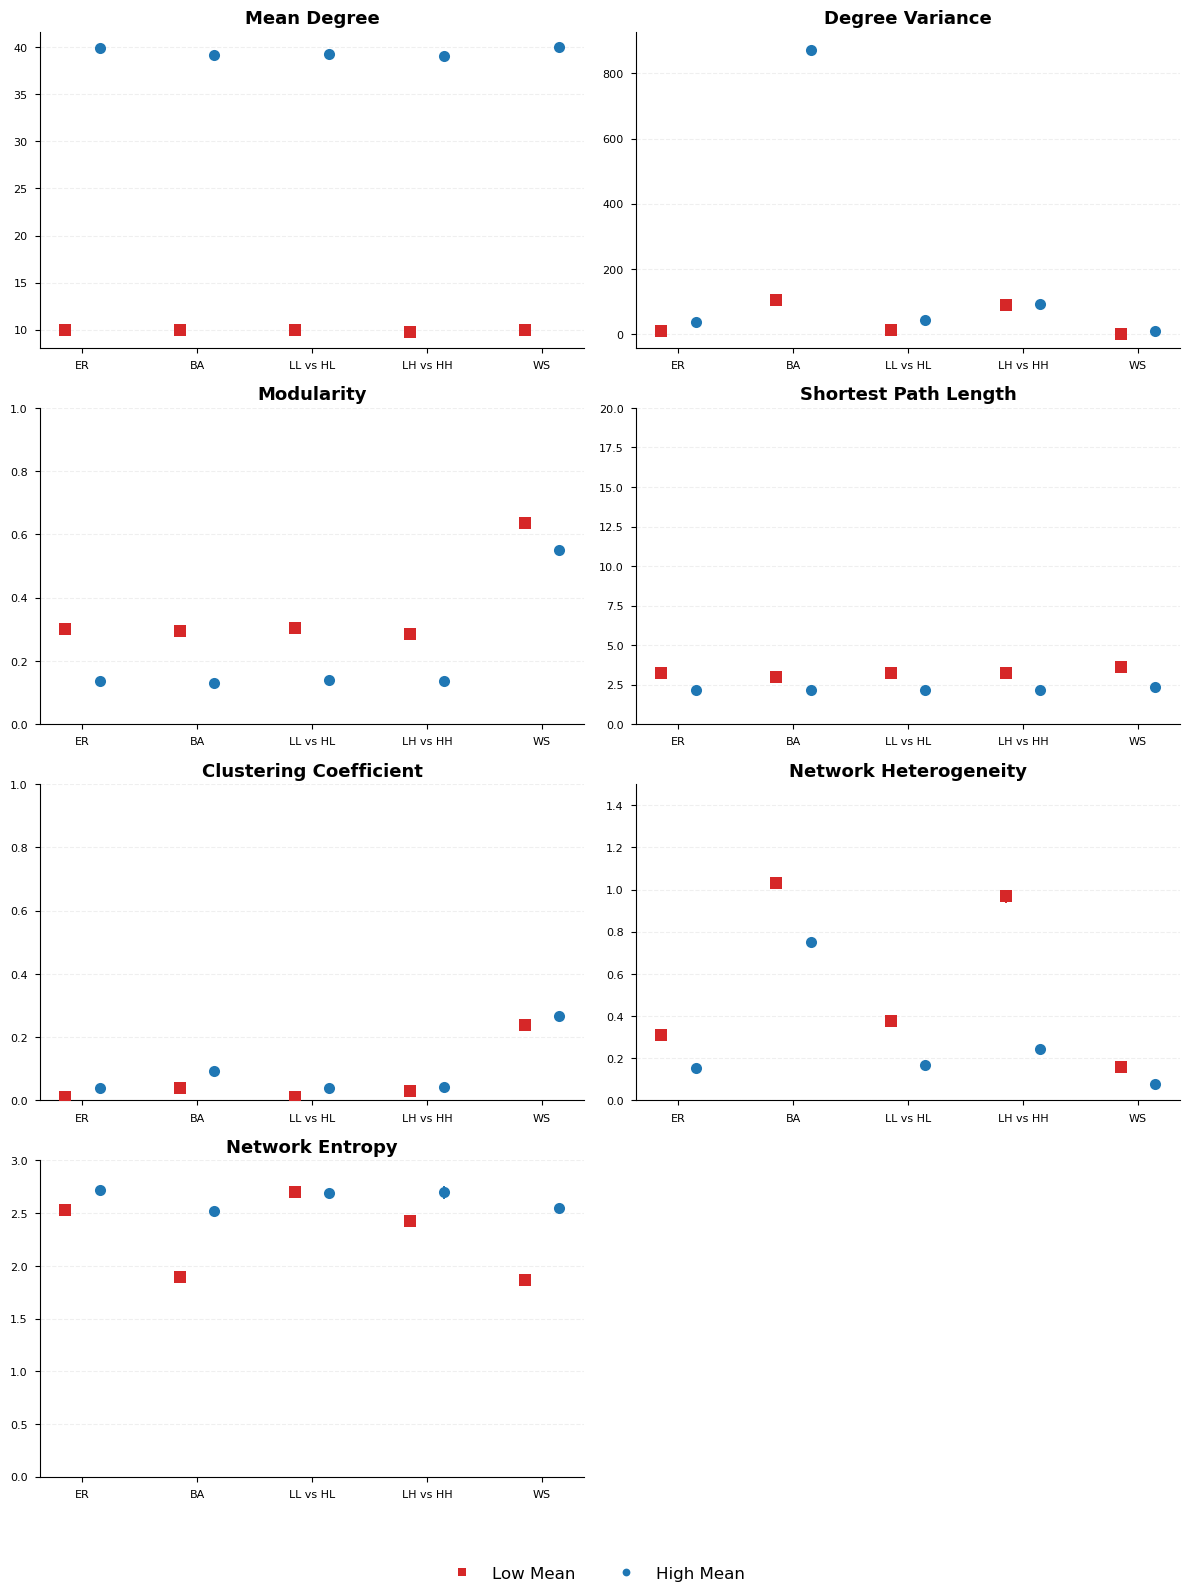

In [58]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# --- CONFIGURATION ---
colors = ['#d62728', '#1f77b4']  # Red (Low), Blue (High)
markers = ['s', 'o']             # Square (Low), Circle (High)

metric_map = {
    'Mean Degree': 'Mean degree',
    'Degree Variance': 'Variance of degree',
    'Modularity': 'Modularity',
    'Shortest Path Length': 'Shortest path length',
    'Clustering Coefficient': 'Clustering coefficient',
    'Network Heterogeneity': 'Heterogeneity score',
    'Network Entropy': 'Entropy'
}

ylim_map = {
    'Modularity': (0, 1),
    'Shortest Path Length': (0, 20),
    'Clustering Coefficient': (0, 1),
    'Network Heterogeneity': (0, 1.5),
    'Network Entropy': (0, 3)
}

# --- PLOTTING ---
fig, axes = plt.subplots(4, 2, figsize=(12, 16), dpi=100)
flat_axes = axes.flatten()

for m_idx, (title, actual_key) in enumerate(metric_map.items()):
    ax = flat_axes[m_idx]
    found_data = False

    for x_pos, (low_name, high_name) in enumerate(pairs_to_compare):
        low_idx = network_names.index(low_name) if low_name in network_names else None
        high_idx = network_names.index(high_name) if high_name in network_names else None

        # Plot Low (Square)
        if low_idx is not None and actual_key in results.get(low_idx, {}):
            item = results[low_idx][actual_key]
            vals = item['values'] if isinstance(item, dict) and 'values' in item else np.array([item.get('mean', 0)])
            mean_val = item.get('mean', np.median(vals)) if isinstance(item, dict) else np.median(vals)
            std_val = item.get('std', 0) if isinstance(item, dict) else 0
            ax.errorbar(
                x_pos + 1 - 0.15,
                mean_val,
                yerr=std_val,
                fmt=markers[0],
                color=colors[0],
                capsize=4,
                markersize=8,
                zorder=5
            )
            found_data = True

        # Plot High (Circle)
        if high_idx is not None and actual_key in results.get(high_idx, {}):
            item = results[high_idx][actual_key]
            vals = item['values'] if isinstance(item, dict) and 'values' in item else np.array([item.get('mean', 0)])
            mean_val = item.get('mean', np.median(vals)) if isinstance(item, dict) else np.median(vals)
            std_val = item.get('std', 0) if isinstance(item, dict) else 0
            ax.errorbar(
                x_pos + 1 + 0.15,
                mean_val,
                yerr=std_val,
                fmt=markers[1],
                color=colors[1],
                capsize=4,
                markersize=8,
                zorder=5
            )
            found_data = True

    # Styling
    ax.set_title(title, fontsize=13, fontweight='bold')
    if title in ylim_map:
        ax.set_ylim(ylim_map[title])
    ax.set_xticks(range(1, len(pairs_to_compare) + 1))
    ax.set_xticklabels(pair_labels, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.2)

    if not found_data:
        ax.text(0.5, 0.5, 'No Data', transform=ax.transAxes, ha='center')

# Clean up
for i in range(len(metric_map), len(flat_axes)):
    flat_axes[i].axis('off')

# Custom Legend
low_h = mlines.Line2D([], [], color=colors[0], marker=markers[0], linestyle='None', label='Low Mean')
high_h = mlines.Line2D([], [], color=colors[1], marker=markers[1], linestyle='None', label='High Mean')
fig.legend(handles=[low_h, high_h], loc='lower center', ncol=2, frameon=False, fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("network_metrics_final.png", dpi=300, bbox_inches='tight')
plt.show()


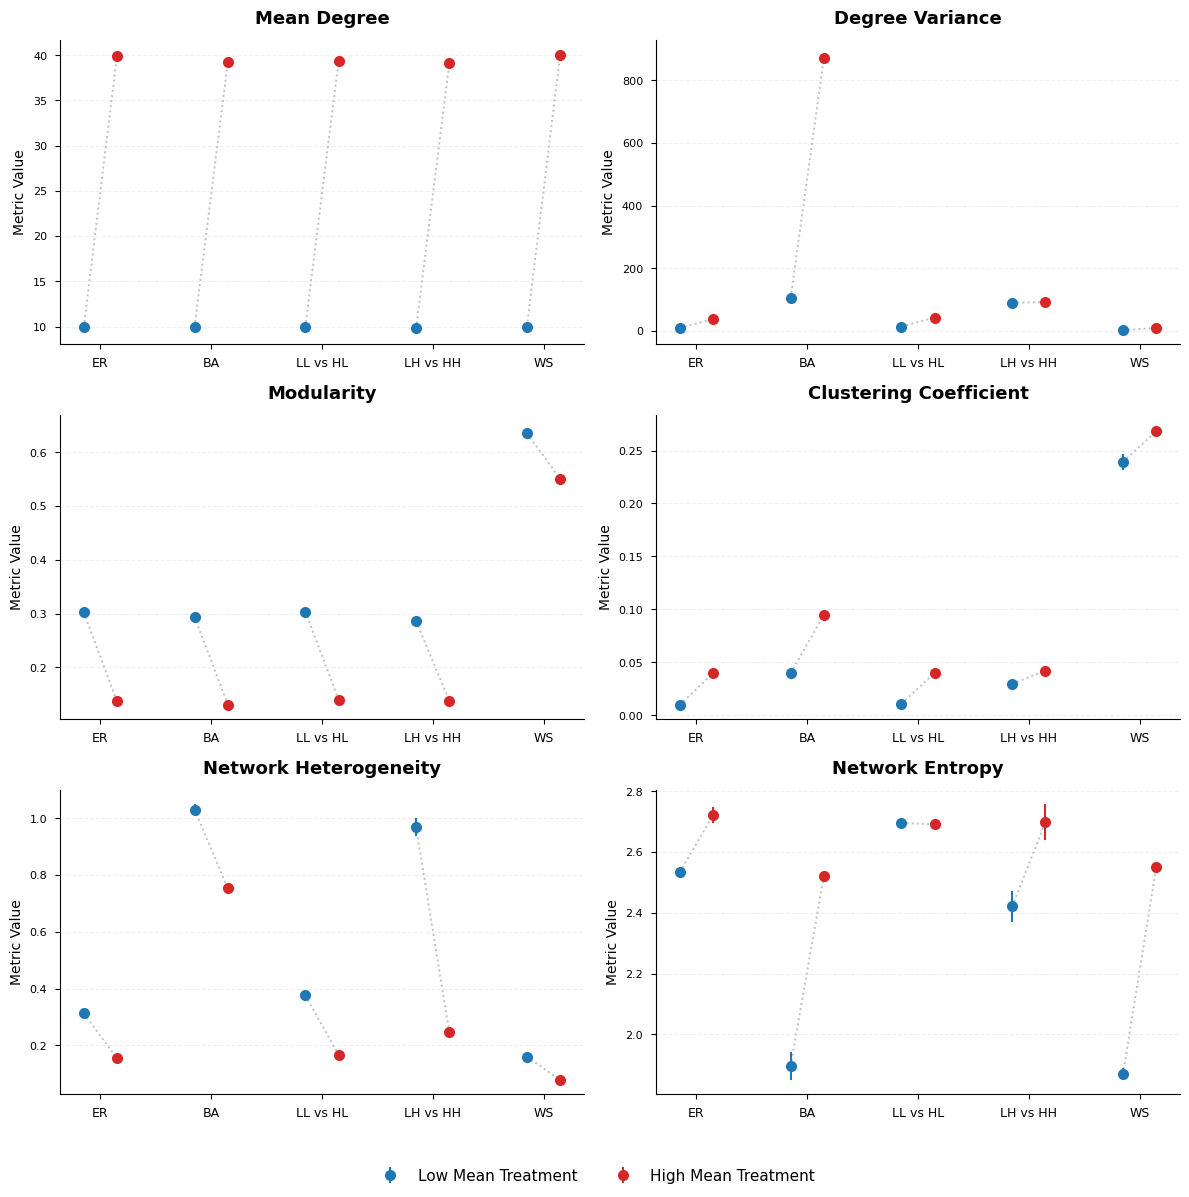

In [55]:
# Professional styling
plt.style.use('seaborn-v0_8-paper')

network_names = [
    'LL', 'LH', 'HL', 'HH',
    'Watts–Strogatz Low mean', 'Watts–Strogatz High mean',
    'Erdős–Rényi Low mean', 'Erdős–Rényi High mean',
    'Fully Connected',
    'Barabási–Albert Low mean', 'Barabási–Albert High mean'
]

pairs_to_compare = [
    ("Erdős–Rényi Low mean", "Erdős–Rényi High mean"),
    ("Barabási–Albert Low mean", "Barabási–Albert High mean"),
    ("LL", "HL"),
    ("LH", "HH"),
    ("Watts–Strogatz Low mean", "Watts–Strogatz High mean")
]
pair_labels = ["ER", "BA", "LL vs HL", "LH vs HH", "WS"]

metrics_to_plot = [
    'Mean degree', 'Variance of degree', 
    'Modularity', 'Clustering coefficient', 
    'Heterogeneity score', 'Entropy'
]

metric_titles = [
    "Mean Degree", "Degree Variance", 
    "Modularity", "Clustering Coefficient", 
    "Network Heterogeneity", "Network Entropy"
]

# ==========================================
# 2. PLOTTING SETUP: 3 Rows, 2 Columns
# ==========================================
n_rows = 3
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), dpi=100)

color_low = '#1f77b4'   
color_high = '#d62728'  

flat_axes = axes.flatten()

for m_idx, metric_key in enumerate(metrics_to_plot):
    ax = flat_axes[m_idx]
    
    # Track handles for the legend
    low_handle, high_handle = None, None
    
    for x_pos, (low_name, high_name) in enumerate(pairs_to_compare):
        low_idx = network_names.index(low_name) if low_name in network_names else None
        high_idx = network_names.index(high_name) if high_name in network_names else None
        
        y_low, y_high = None, None
        
        # --- Plot Low Mean Treatment (Circles with Std) ---
        if low_idx is not None and metric_key in results.get(low_idx, {}):
            low_stats = results[low_idx][metric_key]
            y_low = low_stats["mean"]
            low_handle = ax.errorbar(x_pos - 0.15, y_low, yerr=low_stats["std"], 
                                     fmt='o', color=color_low, markersize=8, 
                                     elinewidth=1.5, capsize=4, 
                                     label='Low Mean' if x_pos == 0 else "")
            
        # --- Plot High Mean Treatment (Circles with Std) ---
        if high_idx is not None and metric_key in results.get(high_idx, {}):
            high_stats = results[high_idx][metric_key]
            y_high = high_stats["mean"]
            high_handle = ax.errorbar(x_pos + 0.15, y_high, yerr=high_stats["std"], 
                                      fmt='o', color=color_high, markersize=8, 
                                      elinewidth=1.5, capsize=4, 
                                      label='High Mean' if x_pos == 0 else "")
                
        # Draw connecting line between the means
        if y_low is not None and y_high is not None:
            ax.plot([x_pos - 0.15, x_pos + 0.15], [y_low, y_high], 
                    color='gray', linestyle=':', alpha=0.5, zorder=0)

    # Styling
    ax.set_title(metric_titles[m_idx], fontsize=13, fontweight='bold', pad=12)
    ax.set_xticks(range(len(pairs_to_compare)))
    ax.set_xticklabels(pair_labels, fontsize=9)
    ax.set_ylabel("Metric Value", fontsize=10)
    
    ax.grid(True, axis='y', linestyle='--', alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Global Legend
fig.legend(
    [low_handle, high_handle], 
    ['Low Mean Treatment', 'High Mean Treatment'], 
    loc='lower center', ncol=2, fontsize=11, frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("network_metrics_2x3_errorbars.png", dpi=300, bbox_inches='tight')
plt.show()

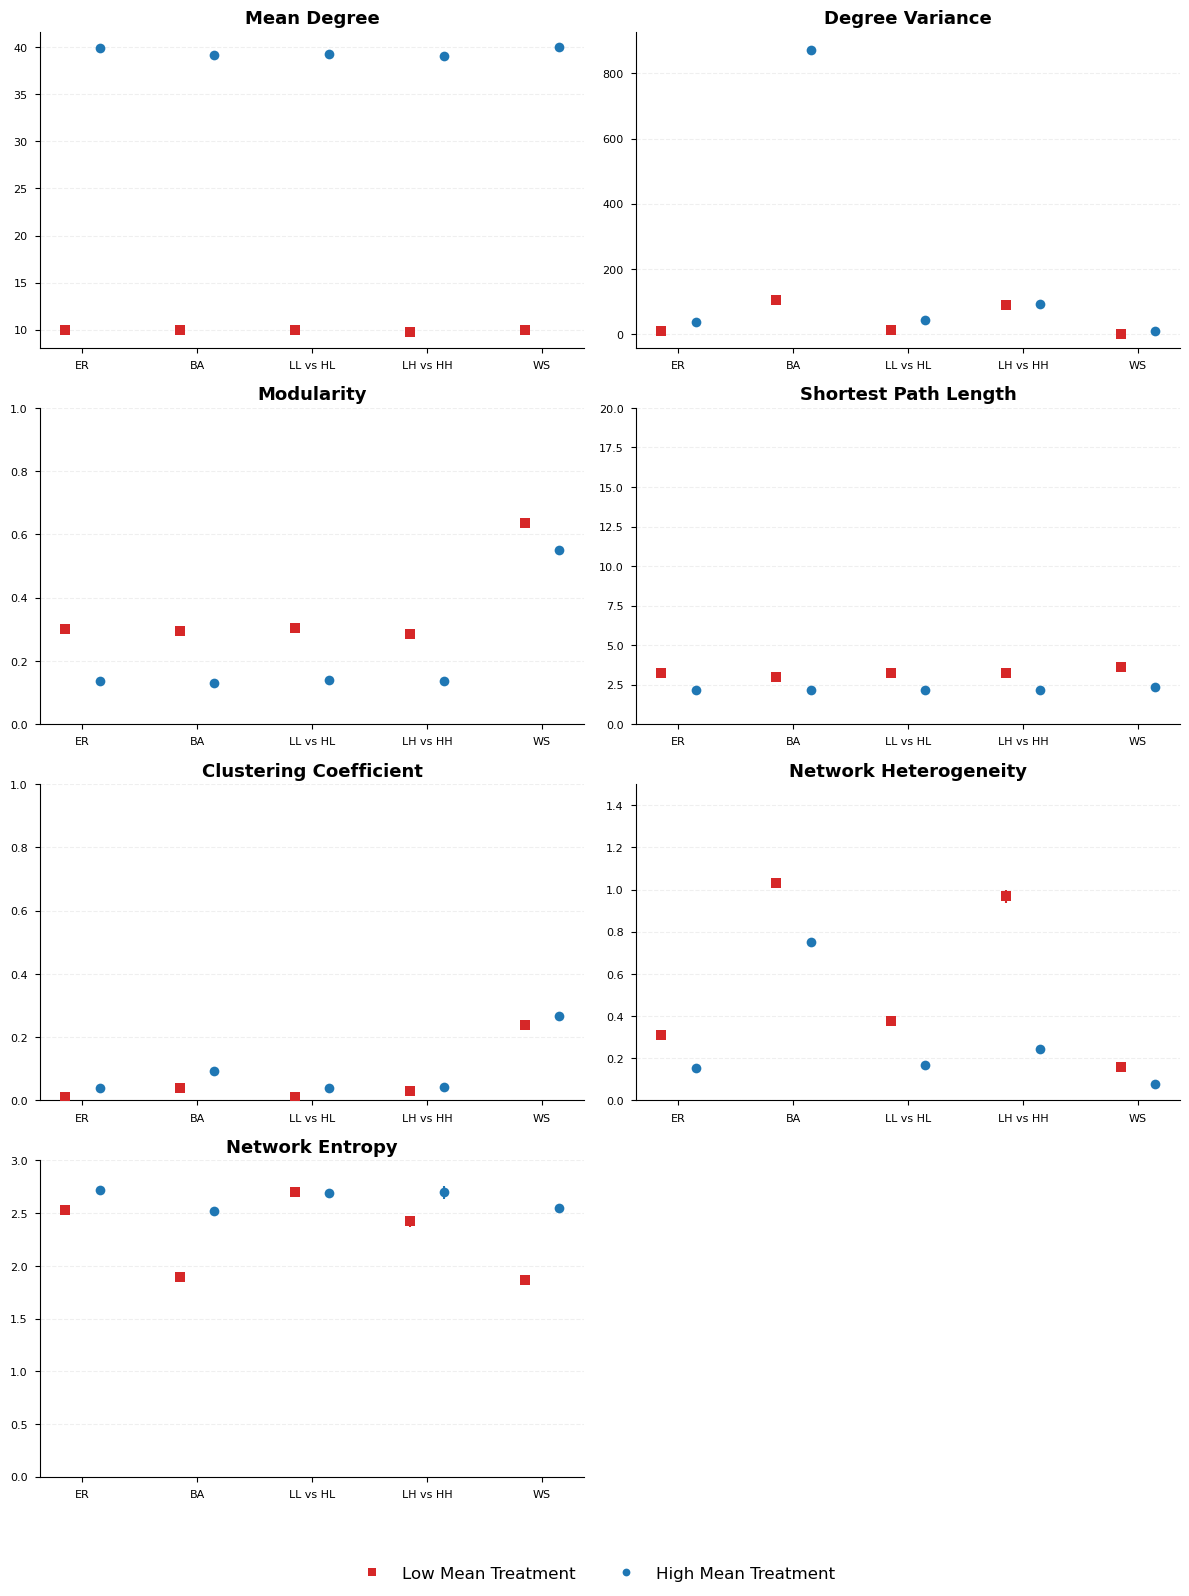

In [59]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# --- CONFIGURATION ---
colors = ['#d62728', '#1f77b4']  # Red (Low), Blue (High)
markers = ['s', 'o']             # Square (Low), Circle (High)

metric_map = {
    'Mean Degree': 'Mean degree',
    'Degree Variance': 'Variance of degree',
    'Modularity': 'Modularity',
    'Shortest Path Length': 'Shortest path length',
    'Clustering Coefficient': 'Clustering coefficient',
    'Network Heterogeneity': 'Heterogeneity score',
    'Network Entropy': 'Entropy'
}

ylim_map = {
    'Modularity': (0, 1),
    'Shortest Path Length': (0, 20),
    'Clustering Coefficient': (0, 1),
    'Network Heterogeneity': (0, 1.5),
    'Network Entropy': (0, 3)
}

# --- PLOTTING ---
fig, axes = plt.subplots(4, 2, figsize=(12, 16), dpi=100)
flat_axes = axes.flatten()

for m_idx, (title, actual_key) in enumerate(metric_map.items()):
    ax = flat_axes[m_idx]
    found_data = False

    for x_pos, (low_name, high_name) in enumerate(pairs_to_compare):
        low_idx = network_names.index(low_name) if low_name in network_names else None
        high_idx = network_names.index(high_name) if high_name in network_names else None

        # Process Low (Square)
        if low_idx is not None and actual_key in results.get(low_idx, {}):
            item = results[low_idx][actual_key]
            mean_val = item.get('mean', 0)
            std_val = item.get('std', 0)
            ax.errorbar(x_pos + 1 - 0.15, mean_val, yerr=std_val, 
                        fmt=markers[0], color=colors[0], ecolor=colors[0], 
                        capsize=3, markersize=7, elinewidth=1.5, zorder=5)
            found_data = True

        # Process High (Circle)
        if high_idx is not None and actual_key in results.get(high_idx, {}):
            item = results[high_idx][actual_key]
            mean_val = item.get('mean', 0)
            std_val = item.get('std', 0)
            ax.errorbar(x_pos + 1 + 0.15, mean_val, yerr=std_val, 
                        fmt=markers[1], color=colors[1], ecolor=colors[1], 
                        capsize=3, markersize=7, elinewidth=1.5, zorder=5)
            found_data = True

    # Styling
    ax.set_title(title, fontsize=13, fontweight='bold')
    if title in ylim_map: ax.set_ylim(ylim_map[title])
    ax.set_xticks(range(1, len(pairs_to_compare) + 1))
    ax.set_xticklabels(pair_labels, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.2)

# Clean up
for i in range(len(metric_map), len(flat_axes)):
    flat_axes[i].axis('off')

# Legend
low_h = mlines.Line2D([], [], color=colors[0], marker=markers[0], linestyle='None', label='Low Mean Treatment')
high_h = mlines.Line2D([], [], color=colors[1], marker=markers[1], linestyle='None', label='High Mean Treatment')
fig.legend(handles=[low_h, high_h], loc='lower center', ncol=2, frameon=False, fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("network_metrics_with_errorbars.png", dpi=300, bbox_inches='tight')
plt.show()